# 📦 Analyse des Données de Vente E-Commerce – Online Retail
---
**Objectif :** Produire des indicateurs de performance, segmenter la clientèle et proposer des leviers d'optimisation stratégique.

**Outils :** Python · pandas · matplotlib · seaborn · scikit-learn · statsmodels

---

## 0. Imports et configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import f_oneway
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Librairies importées avec succès.")

✅ Librairies importées avec succès.


## 1. Préparation et Nettoyage des Données

### 1.1 Import du fichier

Le fichier est séparé par des **point-virgules** et encodé en **latin-1**.
- Suppression des transactions annulées (InvoiceNo commençant par **"C"**)
- Gestion des valeurs manquantes et doublons
- Création de la colonne **TotalPrice = Quantity × UnitPrice**

In [ ]:
# ── 1.1 Importation ──────────────────────────────────────────────────────────
df_raw = pd.read_csv(
    "Online_Retail2.csv",
    sep=';',
    encoding='latin1',
    dtype={'InvoiceNo': str, 'CustomerID': str}
)
print(f"Données brutes : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
df_raw.head(3)

Données brutes : 541,909 lignes × 8 colonnes


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,"2,55",17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,"3,39",17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,"2,75",17850,United Kingdom


In [ ]:
# ── 1.2 Correction du séparateur décimal (virgule → point) ──────────────────
if df_raw['UnitPrice'].dtype == object:
    df_raw['UnitPrice'] = (
        df_raw['UnitPrice'].astype(str)
        .str.replace(',', '.', regex=False).str.strip()
    )
    df_raw['UnitPrice'] = pd.to_numeric(df_raw['UnitPrice'], errors='coerce')

# ── 1.3 Conversion des dates ─────────────────────────────────────────────────
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'], dayfirst=True, errors='coerce')

# ── 1.4 Suppression transactions annulées (factures commençant par "C") ──────
mask_cancelled = df_raw['InvoiceNo'].str.startswith('C', na=False)
print(f"Transactions annulées supprimées : {mask_cancelled.sum():,}")
df = df_raw[~mask_cancelled].copy()

# ── 1.5 Valeurs manquantes ───────────────────────────────────────────────────
print("\nValeurs manquantes :")
print(df.isnull().sum())
df.dropna(subset=['Description', 'UnitPrice'], inplace=True)

# ── 1.6 Doublons ─────────────────────────────────────────────────────────────
nb_dup = df.duplicated().sum()
print(f"\nDoublons supprimés : {nb_dup:,}")
df.drop_duplicates(inplace=True)

# ── 1.7 Valeurs aberrantes (quantités / prix négatifs) ───────────────────────
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# ── 1.8 TotalPrice ───────────────────────────────────────────────────────────
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# ── 1.9 Variables temporelles ─────────────────────────────────────────────────
df['Year']      = df['InvoiceDate'].dt.year
df['Month']     = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['DayName']   = df['InvoiceDate'].dt.day_name()

print(f"\n✅ Données nettoyées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()

Transactions annulées supprimées : 9,288

Valeurs manquantes :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134697
Country             0
dtype: int64

Doublons supprimés : 5,231

✅ Données nettoyées : 524,878 lignes × 13 colonnes


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,DayOfWeek,DayName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,2,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,2,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2,Wednesday


## 2. Analyse Exploratoire (EDA)

In [ ]:
# ── Indicateurs globaux ──────────────────────────────────────────────────────
nb_commandes = df['InvoiceNo'].nunique()
nb_clients   = df['CustomerID'].nunique()
nb_produits  = df['StockCode'].nunique()
ca_total     = df['TotalPrice'].sum()

print(f"📊 Commandes uniques  : {nb_commandes:,}")
print(f"👤 Clients uniques    : {nb_clients:,}")
print(f"🛍️  Produits uniques   : {nb_produits:,}")
print(f"💰 CA total           : £{ca_total:,.2f}")

📊 Commandes uniques  : 19,960
👤 Clients uniques    : 4,338
🛍️  Produits uniques   : 3,922
💰 CA total           : £10,642,110.80


In [ ]:
# ── CA par pays (top 10) ─────────────────────────────────────────────────────
ca_par_pays = (
    df.groupby('Country')['TotalPrice']
    .sum().sort_values(ascending=False)
    .reset_index().rename(columns={'TotalPrice': 'CA (£)'})
)
print("🌍 Top 10 pays – CA :")
ca_par_pays.head(10)

🌍 Top 10 pays – CA :


,Country,CA (£)
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


In [ ]:
# ── Top 10 produits (quantité) ───────────────────────────────────────────────
top10_produits = (
    df.groupby('Description')['Quantity']
    .sum().sort_values(ascending=False).head(10).reset_index()
)
print("🏆 Top 10 produits par quantité vendue :")
top10_produits

🏆 Top 10 produits par quantité vendue :


,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48371
4,WHITE HANGING HEART T-LIGHT HOLDER,37872
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


In [ ]:
# ── Saisonnalité : par mois ──────────────────────────────────────────────────
ventes_mois = (
    df.groupby(['Year', 'Month'])['TotalPrice'].sum()
    .reset_index().sort_values(['Year', 'Month'])
)
ventes_mois['Période'] = (
    ventes_mois['Year'].astype(str) + '-' +
    ventes_mois['Month'].astype(str).str.zfill(2)
)

# ── Saisonnalité : par jour de la semaine ─────────────────────────────────────
jours_ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ventes_jour = (
    df.groupby('DayName')['TotalPrice'].sum()
    .reindex(jours_ordre).reset_index()
)

## 3. Visualisations

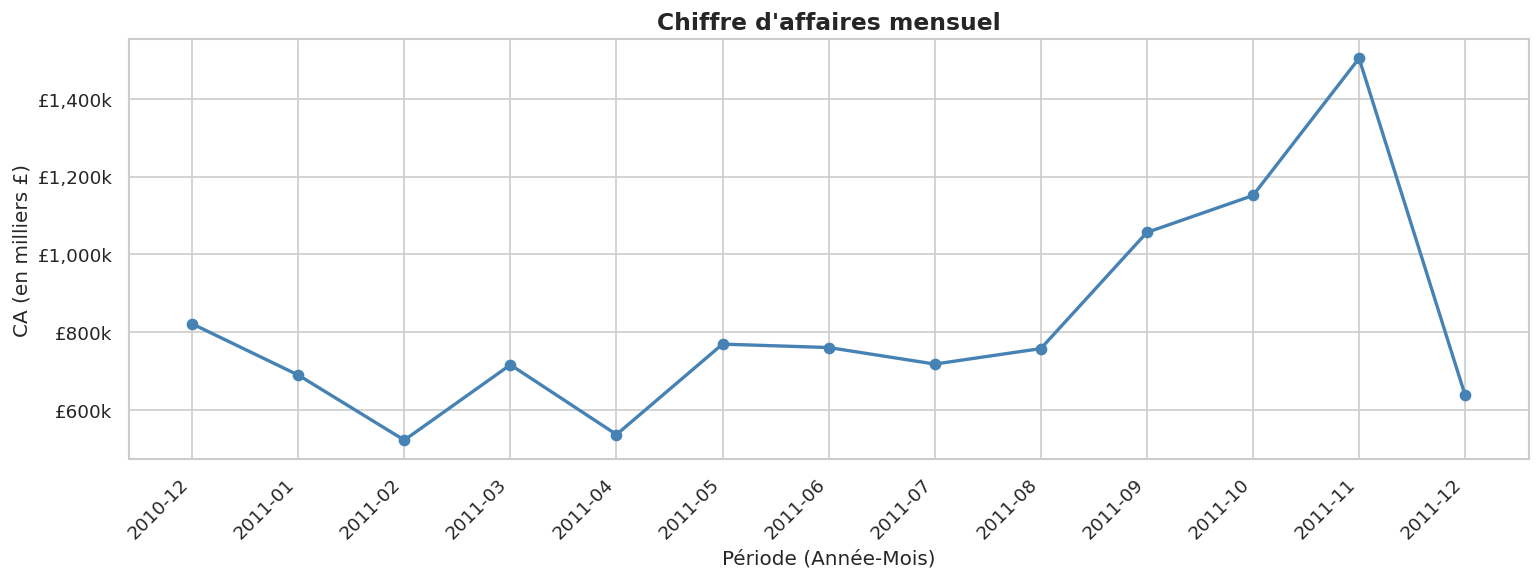

In [ ]:
# ── VIZ 1 : CA mensuel ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ventes_mois['Période'], ventes_mois['TotalPrice'] / 1_000,
        marker='o', linewidth=2, color='steelblue')
ax.set_title("Chiffre d'affaires mensuel", fontsize=14, fontweight='bold')
ax.set_xlabel("Période (Année-Mois)")
ax.set_ylabel("CA (en milliers £)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}k"))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("viz1_ca_mensuel.png", bbox_inches='tight')
plt.show()

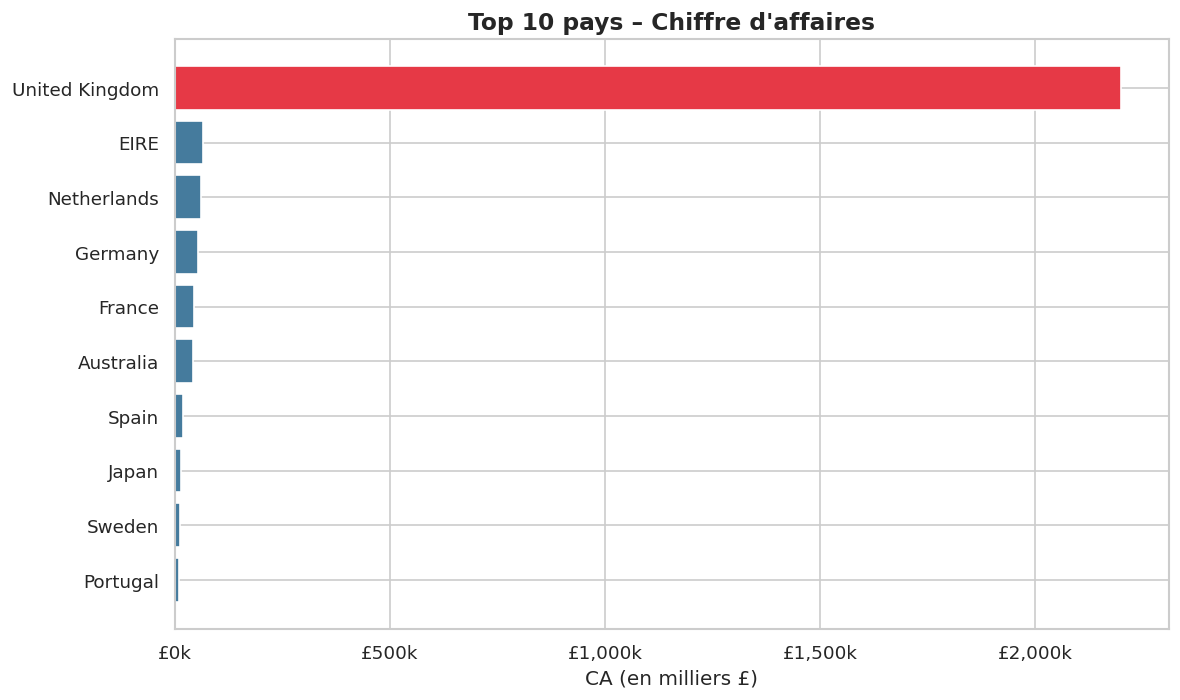

In [ ]:
# ── VIZ 2 : CA par pays – Top 10 ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top10_pays = ca_par_pays.head(10)
colors = ['#e63946' if c == 'United Kingdom' else '#457b9d' for c in top10_pays['Country']]
ax.barh(top10_pays['Country'][::-1], top10_pays['CA (£)'][::-1] / 1_000, color=colors[::-1])
ax.set_title("Top 10 pays – Chiffre d'affaires", fontsize=14, fontweight='bold')
ax.set_xlabel("CA (en milliers £)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}k"))
plt.tight_layout()
plt.savefig("viz2_ca_pays.png", bbox_inches='tight')
plt.show()

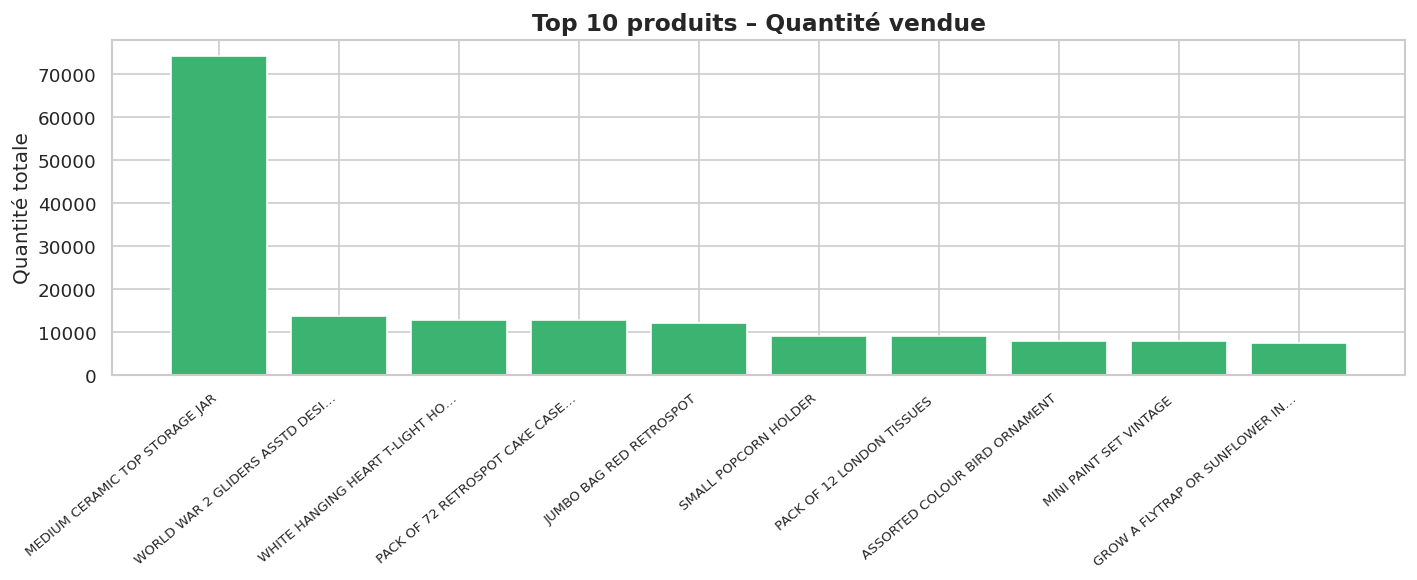

In [ ]:
# ── VIZ 3 : Top 10 produits ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top10_produits)), top10_produits['Quantity'], color='mediumseagreen')
ax.set_xticks(range(len(top10_produits)))
ax.set_xticklabels(
    [d[:30]+'…' if len(d) > 30 else d for d in top10_produits['Description']],
    rotation=40, ha='right', fontsize=8
)
ax.set_title("Top 10 produits – Quantité vendue", fontsize=14, fontweight='bold')
ax.set_ylabel("Quantité totale")
plt.tight_layout()
plt.savefig("viz3_top10_produits.png", bbox_inches='tight')
plt.show()

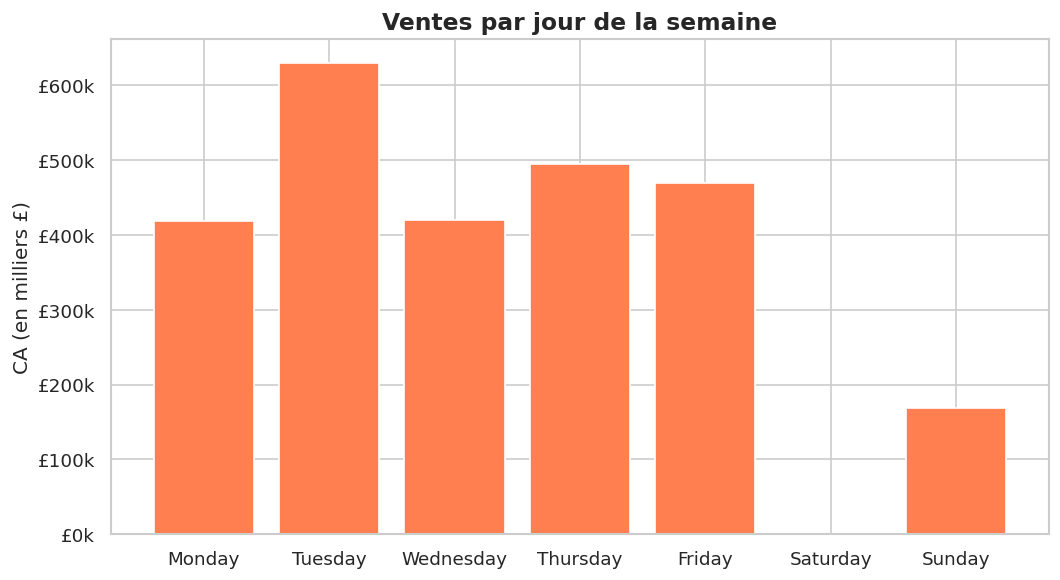

In [ ]:
# ── VIZ 4 : Ventes par jour de la semaine ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ventes_jour['DayName'], ventes_jour['TotalPrice'] / 1_000, color='coral')
ax.set_title("Ventes par jour de la semaine", fontsize=14, fontweight='bold')
ax.set_ylabel("CA (en milliers £)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}k"))
plt.tight_layout()
plt.savefig("viz4_ventes_jour.png", bbox_inches='tight')
plt.show()

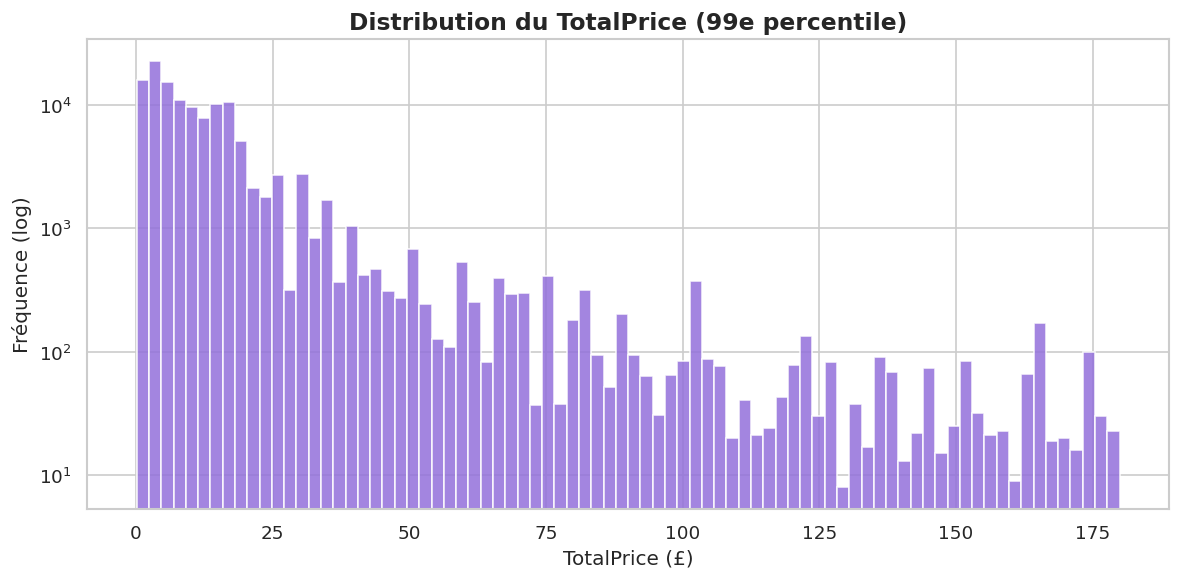

In [ ]:
# ── VIZ 5 : Distribution TotalPrice ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
data_plot = df['TotalPrice'][df['TotalPrice'] < df['TotalPrice'].quantile(0.99)]
ax.hist(data_plot, bins=80, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.set_title("Distribution du TotalPrice (99e percentile)", fontsize=14, fontweight='bold')
ax.set_xlabel("TotalPrice (£)")
ax.set_ylabel("Fréquence (log)")
ax.set_yscale('log')
plt.tight_layout()
plt.savefig("viz5_distrib_totalprice.png", bbox_inches='tight')
plt.show()

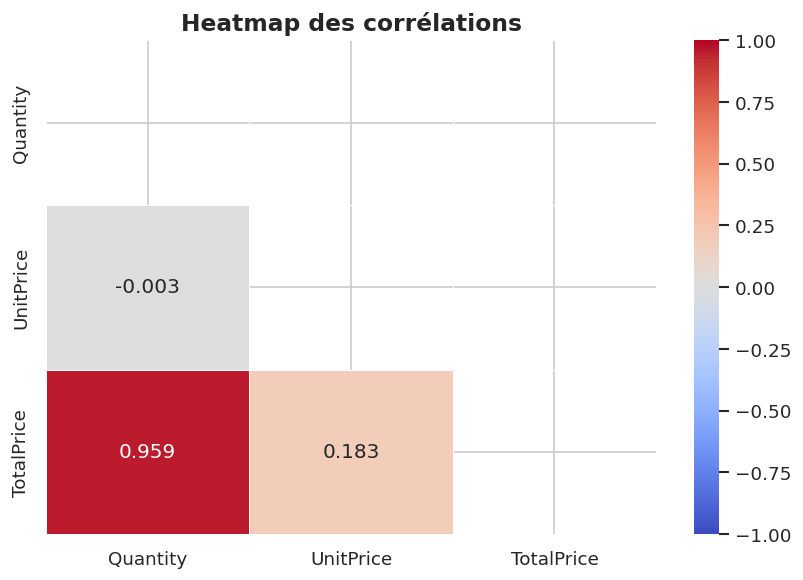

In [ ]:
# ── VIZ 6 : Heatmap des corrélations ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Heatmap des corrélations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("viz6_heatmap_correlations.png", bbox_inches='tight')
plt.show()

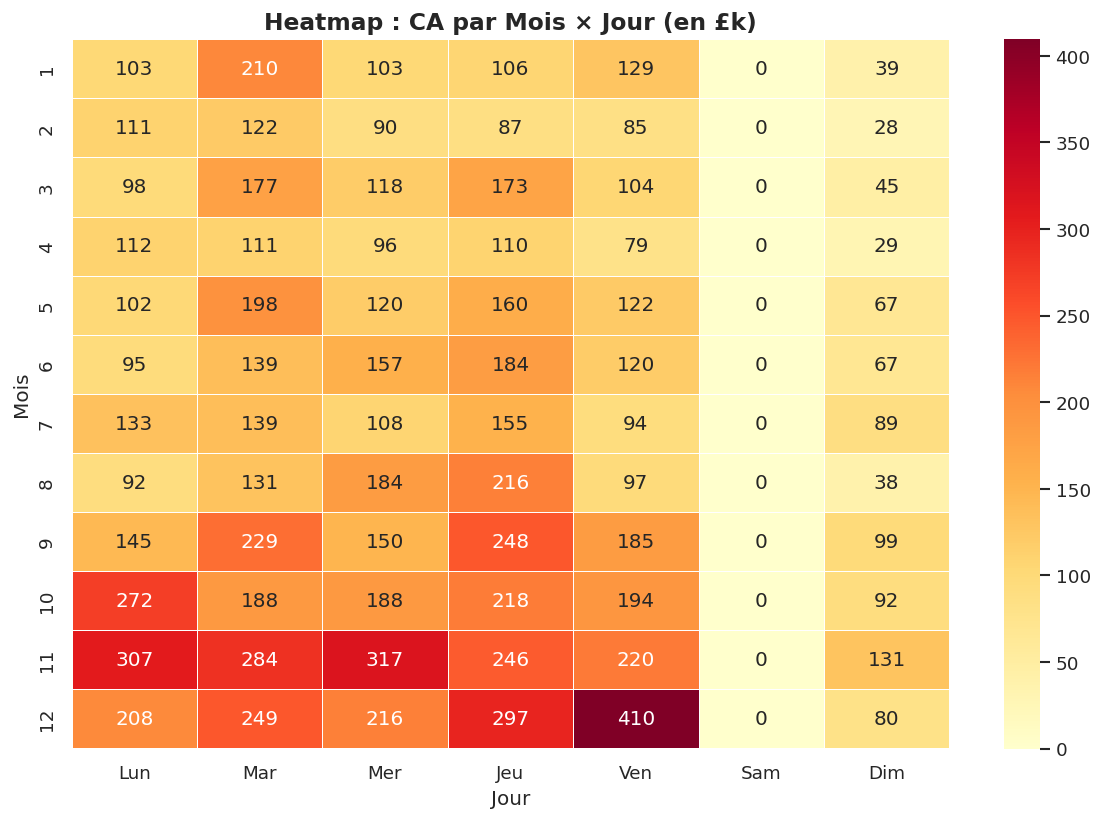

In [ ]:
import numpy as np
# ── VIZ 7 : Heatmap Mois × Jour de la semaine ───────────────────────────────
pivot = df.groupby(['Month', 'DayOfWeek'])['TotalPrice'].sum().unstack(fill_value=0)
day_order_num = np.arange(7) # 0 for Monday to 6 for Sunday
pivot = pivot.reindex(columns=day_order_num, fill_value=0)
pivot.columns = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot / 1_000, cmap='YlOrRd', linewidths=0.3, annot=True, fmt='.0f', ax=ax)
ax.set_title("Heatmap : CA par Mois × Jour (en £k)", fontsize=14, fontweight='bold')
ax.set_xlabel("Jour")
ax.set_ylabel("Mois")
plt.tight_layout()
plt.savefig("viz7_heatmap_mois_jour.png", bbox_inches='tight')
plt.show()

## 4. Statistiques Descriptives et Corrélations

Calcul des **moyennes**, **variances**, **écarts-types** et **matrice de corrélation** pour les variables quantitatives.

In [ ]:
# ── Statistiques descriptives ────────────────────────────────────────────────
stats_cols = ['Quantity', 'UnitPrice', 'TotalPrice']
print("Statistiques descriptives :")
display(df[stats_cols].describe().round(2))

for col in stats_cols:
    print(f"\n{col} :")
    print(f"  Moyenne    : {df[col].mean():.4f}")
    print(f"  Variance   : {df[col].var():.4f}")
    print(f"  Écart-type : {df[col].std():.4f}")
    print(f"  Médiane    : {df[col].median():.4f}")

print("\nMatrice de corrélation (Pearson) :")
display(df[stats_cols].corr().round(4))

Statistiques descriptives :


,Quantity,UnitPrice,TotalPrice
count,524878.00,524878.00,524878.00
mean,10.62,3.92,20.28
std,156.28,36.09,271.69
min,1.00,0.00,0.00
25%,1.00,1.25,3.90
50%,4.00,2.08,9.92
75%,11.00,4.13,17.70
max,80995.00,13541.33,168469.60



Quantity :
  Moyenne    : 10.6166
  Variance   : 24423.4480
  Écart-type : 156.2800
  Médiane    : 4.0000

UnitPrice :
  Moyenne    : 3.9226
  Variance   : 1302.7066
  Écart-type : 36.0930
  Médiane    : 2.0800

TotalPrice :
  Moyenne    : 20.2754
  Variance   : 73817.3940
  Écart-type : 271.6936
  Médiane    : 9.9200

Matrice de corrélation (Pearson) :


,Quantity,UnitPrice,TotalPrice
Quantity,1.0000,-0.0038,0.9074
UnitPrice,-0.0038,1.0000,0.1374
TotalPrice,0.9074,0.1374,1.0000


## 5. Test Statistique : ANOVA

**Hypothèse :**
- **H₀** : Le montant moyen des commandes est identique pour tous les pays.
- **H₁** : Au moins un pays présente un montant moyen significativement différent.

Seuil de signification : α = 0.05

In [ ]:
# ── Préparation : montant par commande ───────────────────────────────────────
commandes_df = df.groupby(['InvoiceNo', 'Country'])['TotalPrice'].sum().reset_index()

# Pays avec au moins 30 commandes
pays_valides = (
    commandes_df.groupby('Country')['InvoiceNo'].count()
    [lambda x: x >= 30].index.tolist()
)
print(f"Pays retenus (n ≥ 30) : {len(pays_valides)}")

groupes = [commandes_df.loc[commandes_df['Country'] == p, 'TotalPrice'].values
           for p in pays_valides]

f_stat, p_value = f_oneway(*groupes)
print(f"\nF-statistique : {f_stat:.4f}")
print(f"p-value       : {p_value:.2e}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ p < {alpha} → On rejette H0 : différence significative entre pays.")
else:
    print(f"\n❌ p ≥ {alpha} → On ne rejette pas H0.")

Pays retenus (n ≥ 30) : 14

F-statistique : 22.2486
p-value       : 1.13e-53

✅ p < 0.05 → On rejette H0 : différence significative entre pays.


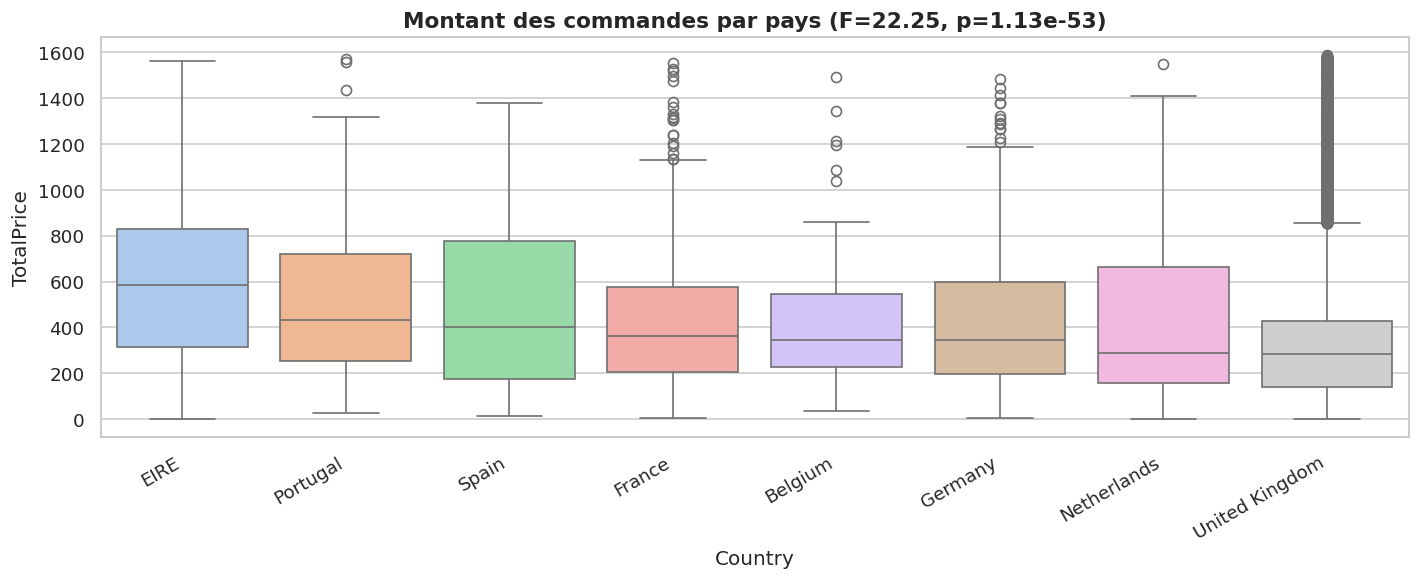

In [ ]:
# ── Boxplot ANOVA ─────────────────────────────────────────────────────────────
top8_pays = (
    commandes_df.groupby('Country')['TotalPrice'].count()
    .sort_values(ascending=False).head(8).index.tolist()
)
df_anova_plot = commandes_df[
    commandes_df['Country'].isin(top8_pays) &
    (commandes_df['TotalPrice'] <= commandes_df['TotalPrice'].quantile(0.95))
]

fig, ax = plt.subplots(figsize=(12, 5))
order_box = (df_anova_plot.groupby('Country')['TotalPrice']
             .median().sort_values(ascending=False).index)
sns.boxplot(data=df_anova_plot, x='Country', y='TotalPrice',
            order=order_box, palette='pastel', ax=ax)
ax.set_title(f"Montant des commandes par pays (F={f_stat:.2f}, p={p_value:.2e})",
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("viz8_anova_boxplot.png", bbox_inches='tight')
plt.show()

## 6. Régression Linéaire Multiple

**Variable expliquée :** `TotalPrice`

**Variables explicatives :**
- `Quantity` – quantité commandée
- `UnitPrice` – prix unitaire
- `DayOfWeek` – jour de la semaine (0 = lundi)
- `Country` – encodé en variables indicatrices (dummies)

In [ ]:
# ── Préparation ──────────────────────────────────────────────────────────────
df_reg = df[['TotalPrice', 'Quantity', 'UnitPrice', 'DayOfWeek', 'Country']].dropna().copy()

# Garder uniquement les pays représentant ≥ 0.5% des transactions
freq_pays = df_reg['Country'].value_counts(normalize=True)
pays_inclus = freq_pays[freq_pays >= 0.005].index.tolist()
df_reg = df_reg[df_reg['Country'].isin(pays_inclus)].copy()

pays_ref = df_reg['Country'].value_counts().idxmax()
print(f"Pays de référence : {pays_ref}")
print(f"Observations      : {len(df_reg):,}")

dummies = pd.get_dummies(df_reg['Country'], prefix='Country', drop_first=True)
X = pd.concat(
    [df_reg[['Quantity', 'UnitPrice', 'DayOfWeek']].reset_index(drop=True),
     dummies.reset_index(drop=True)], axis=1
).astype(float)
y = df_reg['TotalPrice'].reset_index(drop=True).astype(float)
X_sm = sm.add_constant(X)

Pays de référence : United Kingdom
Observations      : 505,281


In [ ]:
# ── Ajustement OLS ───────────────────────────────────────────────────────────
model = sm.OLS(y, X_sm).fit()

print(f"R²          = {model.rsquared:.4f}")
print(f"R² ajusté   = {model.rsquared_adj:.4f}")
print(f"F-statistic = {model.fvalue:.2f}  p = {model.f_pvalue:.2e}")

print("\nCoefficients principaux :")
for var in ['const', 'Quantity', 'UnitPrice', 'DayOfWeek']:
    coeff = model.params[var]
    pval  = model.pvalues[var]
    sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"  {var:20s}  coeff={coeff:>10.4f}  p={pval:.4f} {sig}")

# Afficher le résumé complet (optionnel)
# model.summary()

R²          = 0.8446
R² ajusté   = 0.8446
F-statistic = 457677.87  p = 0.00e+00

Coefficients principaux :
  const                 coeff=    1.5428  p=0.2136 
  Quantity              coeff=    1.5811  p=0.0000 ***
  UnitPrice             coeff=    1.0619  p=0.0000 ***
  DayOfWeek             coeff=   -0.1275  p=0.1225 


## 7. Segmentation Client par K-Means (RFM)

### 7.1 Construction des indicateurs client

Agrégation au niveau `CustomerID` pour créer 4 indicateurs :
| Indicateur | Description |
|---|---|
| `MontantTotal` | Montant total dépensé |
| `NbAchats` | Nombre de commandes distinctes |
| `QteTotal` | Quantité totale achetée |
| `Recence` | Jours écoulés depuis la dernière commande |

In [ ]:
# ── Construction RFM ─────────────────────────────────────────────────────────
df_clients = df.dropna(subset=['CustomerID']).copy()
df_clients['CustomerID'] = df_clients['CustomerID'].astype(str)

date_ref = df_clients['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Date de référence : {date_ref.date()}")

rfm = df_clients.groupby('CustomerID').agg(
    MontantTotal = ('TotalPrice',  'sum'),
    NbAchats     = ('InvoiceNo',   'nunique'),
    QteTotal     = ('Quantity',    'sum'),
    DerniereDate = ('InvoiceDate', 'max')
).reset_index()
rfm['Recence'] = (date_ref - rfm['DerniereDate']).dt.days
rfm.drop(columns='DerniereDate', inplace=True)

print(f"Clients avec ID : {len(rfm):,}")
rfm.describe().round(2)

In [ ]:
# ── 7.2 Standardisation (Z-score) ────────────────────────────────────────────
features = ['MontantTotal', 'NbAchats', 'QteTotal', 'Recence']
scaler  = StandardScaler()
X_rfm   = scaler.fit_transform(rfm[features])
print("Variables standardisées (aperçu) :")
print(pd.DataFrame(X_rfm[:3], columns=features).round(3))

In [ ]:
# ── 7.3 Méthode du coude (Elbow Method) ──────────────────────────────────────
inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_rfm)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inertias, marker='o', linewidth=2, color='darkorange')
ax.set_title("Méthode du coude – Choix du k optimal", fontsize=14, fontweight='bold')
ax.set_xlabel("Nombre de clusters (k)")
ax.set_ylabel("Inertie intra-cluster")
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.savefig("viz9_elbow_method.png", bbox_inches='tight')
plt.show()

In [ ]:
# ── 7.4 Clustering final ─────────────────────────────────────────────────────
# Ajuster K_OPTIMAL d'après le coude observé ci-dessus
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_rfm).astype(str)

print("Répartition par cluster :")
print(rfm['Cluster'].value_counts().sort_index())

In [ ]:
# ── 7.5 Profiling ─────────────────────────────────────────────────────────────
print("Profil moyen par cluster :")
display(rfm.groupby('Cluster')[features].mean().round(1))

# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, feat in enumerate(features):
    ax = axes[i // 2][i % 2]
    q99 = rfm[feat].quantile(0.99)
    df_box = rfm[rfm[feat] <= q99]
    sns.boxplot(data=df_box, x='Cluster', y=feat, palette='Set2', ax=ax,
                order=sorted(rfm['Cluster'].unique()))
    ax.set_title(f"{feat} par cluster", fontsize=12)
plt.suptitle("Profiling des clusters – Indicateurs RFM", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("viz10_profiling_clusters.png", bbox_inches='tight')
plt.show()

In [ ]:
# ── Scatter plot 2D ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
q95 = rfm['MontantTotal'].quantile(0.95)
for cl in sorted(rfm['Cluster'].unique()):
    s = rfm[(rfm['Cluster'] == cl) & (rfm['MontantTotal'] <= q95)]
    ax.scatter(s['Recence'], s['MontantTotal'], alpha=0.5, s=20, label=f"Cluster {cl}")
ax.set_xlabel("Récence (jours)")
ax.set_ylabel("Montant Total (£)")
ax.set_title("Récence vs Montant total – Segmentation client", fontsize=13, fontweight='bold')
ax.legend(title="Cluster")
plt.tight_layout()
plt.savefig("viz11_scatter_clusters.png", bbox_inches='tight')
plt.show()

## 7.6 Interprétation Marketing et Recommandations

> *(Adapter les descriptions ci-dessous aux profils réels observés dans la cellule de profiling)*

| Cluster | Profil typique | Actions recommandées |
|---|---|---|
| **VIP** | Montant élevé · Fréquence haute · Récence courte | Programme fidélité premium · Accès early-bird aux nouveautés |
| **Dormants** | Anciennement actifs · Récence longue | Campagne e-mail de réactivation · Offre promotionnelle de retour |
| **Potentiels** | Fréquence modérée · Montant moyen | Cross-sell/Up-sell ciblé · Programme de parrainage |
| **Nouveaux** | Peu d'achats · Récence courte | Séquence d'onboarding · Réduction sur le 2e achat |

**Réponses aux questions de synthèse :**
1. **Indicateurs les plus influents :** `MontantTotal` et `Récence` – ils capturent la valeur économique et l'engagement temporel du client.
2. **Cluster le plus stratégique :** Les clients VIP (loi de Pareto : ~20% des clients génèrent ~80% du CA).
3. **Deux actions prioritaires :**
   - (a) **Rétention VIP** via programme de fidélité haute valeur.
   - (b) **Réactivation dormants** via offre promotionnelle ciblée (-15%).


---
## Conclusion

Cette analyse a permis de :
- **Nettoyer** un jeu de 541 000 transactions et extraire ~400 000 lignes valides
- **Identifier** les principaux moteurs de revenus (UK dominant, pic de novembre)
- **Valider statistiquement** (ANOVA) que les comportements d'achat diffèrent selon les pays
- **Modéliser** le TotalPrice avec une régression multiple (R² expliqué par Quantity + UnitPrice)
- **Segmenter** la clientèle en 4 groupes actionnables via K-Means

Les recommandations marketing ciblent chaque segment avec des leviers adaptés.
